# Model Project

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

## 2 Solving the model numerically

In [2]:
from Our_Consumer import ConsumerClass

### 2.1 A two-dimensional grid search

#### 2.1.1 Making the grid

In [3]:
model_complements = ConsumerClass()
model_complements.solve_grid();

s1=0.5377
s2=0.2021
s3=0.2602
w=0.4372
u=3.4016


In [4]:
model_subtitutes = ConsumerClass(par={"sigma_B":3.0})
model_subtitutes.solve_grid();

s1=0.5377
s2=0.3206
s3=0.1417
w=0.6935
u=3.4851


#### 2.1.2 Plot

##### Bus and train complements

s1=0.5377
s2=0.2021
s3=0.2602
w=0.4372
u=3.4016


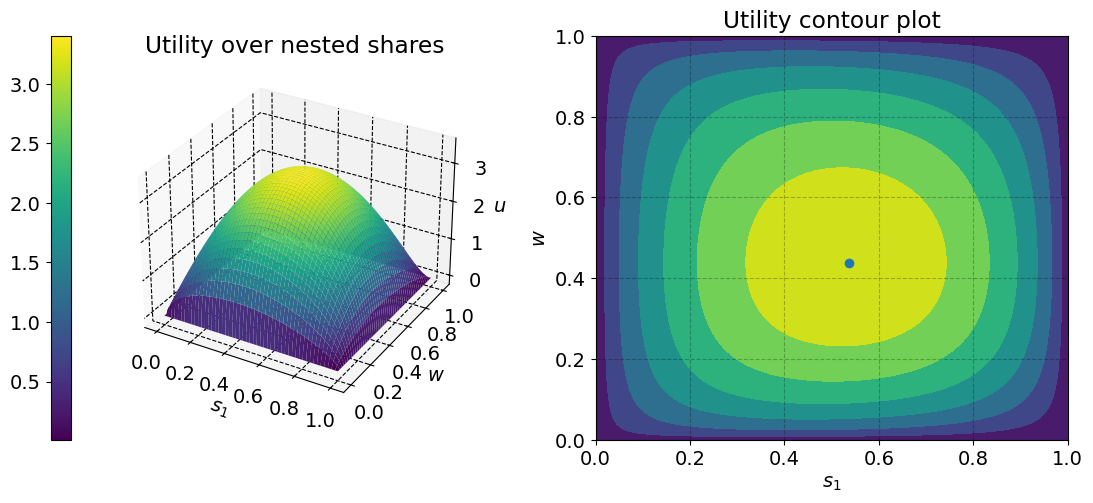

In [5]:
model_complements = ConsumerClass()

opt_complements = model_complements.solve_grid(N=200)
fig= model_complements.plot_grid(opt_complements)

##### Bus and trains subtitutes

s1=0.5377
s2=0.3206
s3=0.1417
w=0.6935
u=3.4851


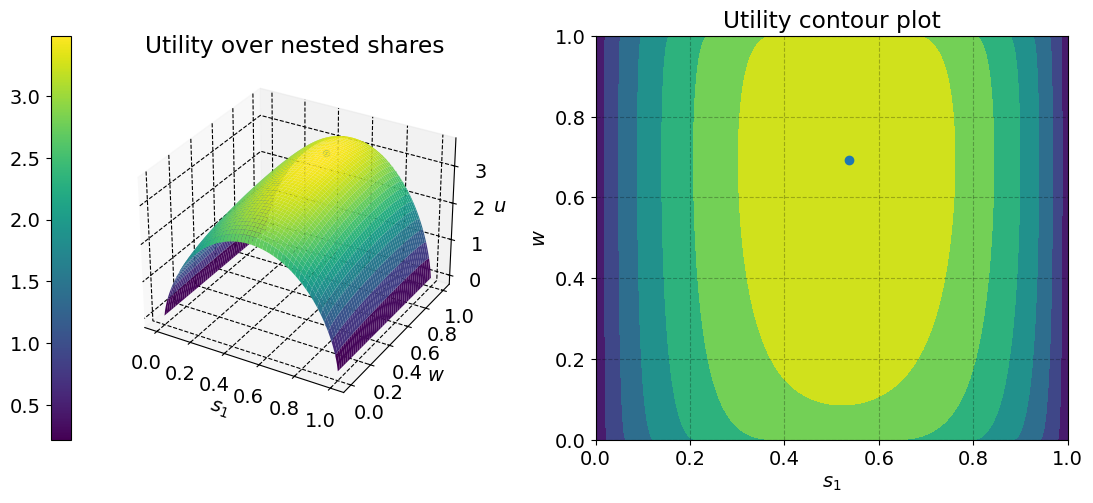

In [6]:
model_subtitutes = ConsumerClass(par={"sigma_B":3.0})

opt_subtitutes = model_subtitutes.solve_grid(N=200)
fig= model_subtitutes.plot_grid(opt_subtitutes)

#### 2.1.3 Different values of N

##### Bus and train complements

In [7]:
from Our_Consumer import ConsumerClass

model = ConsumerClass()

grid_N50 = model.solve_grid(N=50)

s1=0.5306
s2=0.2107
s3=0.2586
w=0.4490
u=3.4007


In [8]:
grid_N100 = model.solve_grid(N=100)

s1=0.5354
s2=0.2065
s3=0.2581
w=0.4444
u=3.4015


In [9]:
grid_N500 = model.solve_grid(N=500)

s1=0.5351
s2=0.2040
s3=0.2609
w=0.4389
u=3.4017


In [10]:
grid_N1000 = model.solve_grid(N=1000)

s1=0.5355
s2=0.2041
s3=0.2604
w=0.4394
u=3.4017


##### Bus and trains subtitutes

In [11]:
model_subtitutes = ConsumerClass(par={"sigma_B":3.0})

opt_subtitutes = model_subtitutes.solve_grid(N=50)

s1=0.5306
s2=0.3257
s3=0.1437
w=0.6939
u=3.4846


In [12]:
model_subtitutes = ConsumerClass(par={"sigma_B":3.0})

opt_subtitutes = model_subtitutes.solve_grid(N=100)

s1=0.5354
s2=0.3238
s3=0.1408
w=0.6970
u=3.4850


In [13]:
model_subtitutes = ConsumerClass(par={"sigma_B":3.0})

opt_subtitutes = model_subtitutes.solve_grid(N=500)

s1=0.5391
s2=0.3187
s3=0.1422
w=0.6914
u=3.4851


In [14]:
model_subtitutes = ConsumerClass(par={"sigma_B":3.0})

opt_subtitutes = model_subtitutes.solve_grid(N=1000)

s1=0.5385
s2=0.3197
s3=0.1418
w=0.6927
u=3.4851


#### The cost of one ekstra u

A problem of size  N cost N^2 evaluations of u. 

When we add one ekstra N, the expression becomes:
(N+1)(N+1) = N^2+2N+1

If we subtract the original cost (N^2), from the cost when adding one ekstra N we get:

N^2-N^2+2N+1 = 2N+1

This means that each time N is increased by 1, it requires 2N+1 additional evaluations of u.

#### How does increasing N improve u?

An increase in N expands the grid used in the search, which increases the amount of points to choose from. This improves the chance of finding the true optimal point, which is why u grows slightly as N increase:

Complements:
u = 3.4007 (N=50)
u = 3.4015 (N=100)
u = 3.4017 (N=500)
u = 3.4017 (N=1000)

Substitutes:
u = 3.4846 (N=50)
u = 3.4850 (N=100)
u = 3.4851 (N=500)
u = 3.4851 (N=1000)

However,the gain in u shrinks quickly as N increase, while the cost keeps growing, since eazch additional N cost 2N+1 extra valuations of u. beoynd N=500 the gain start to vanish. This is the case for both the calibrations. A finer grid gives more precise results, but at a certin point the cost of extra evaluations outweighs the improvement in u.

#### 2.1.4 Comparing the two calibrations

##### Bus and train complements

s1=0.5377
s2=0.2021
s3=0.2602
w=0.4372
u=3.4016


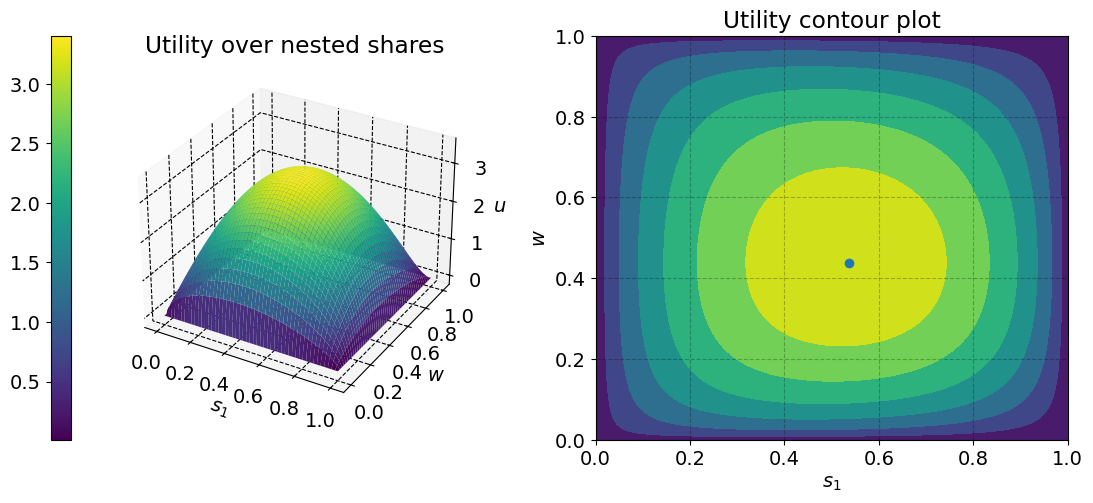

In [15]:
model_complements = ConsumerClass()

opt_complements = model_complements.solve_grid(N=200)
fig= model_complements.plot_grid(opt_complements)

When bus and train are complements the surface is a smooth rounded dome.The contour lines are formed in an oval shape around the optimum. The surface is steepest around the corners of the dome and gets flater the closer to the optimum it gets, but it doesn´t have a large flat area.

##### Bus and trains subtitutes

s1=0.5377
s2=0.3206
s3=0.1417
w=0.6935
u=3.4851


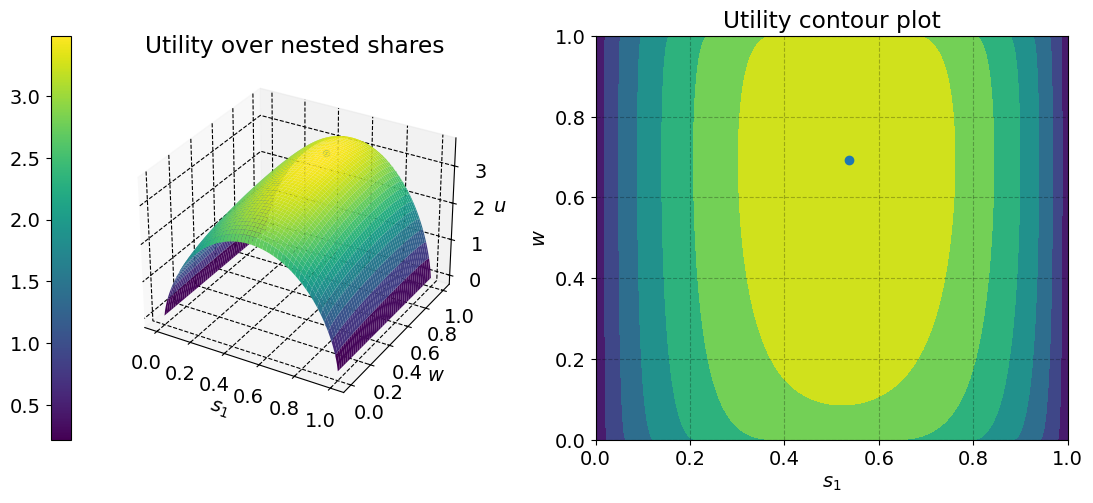

In [16]:
model_subtitutes = ConsumerClass(par={"sigma_B":3.0})

opt_subtitutes = model_subtitutes.solve_grid(N=200)
fig= model_subtitutes.plot_grid(opt_subtitutes)

The surface looks very different when bus and train are substitutes. Now it looks more like a curved tunnel. The contour lines are very steep in the two sides of the surface, but it gets a bit flatter the closer to the top it gets. Utility thereby only changes very slightly as w increases, but it falls heavily when s1 moves away from its optimal point. The surface is thereby relatively flat around the w-axis, when s1 is at its optimal point.

#### Comparison of the two calibrations

We expect the substitute calibration to be the hardest one to optimize, because it has a bigger flatter area compared to the complement calibration. Even though the substitute calibration reaches the highest utility, it has a large area where the gradient is close to zero. This makes it harder for the optimizer to find the optimal value of w because the utility only changes very slightly as w increases, thereby making it hard for the optimizer to know what direction to move.

### 2.1 L-BFGS-B

#### 2.2.1 solution L-BFGS-B

##### Bus and train complements

In [17]:
from Our_Consumer import ConsumerClass

consumer = ConsumerClass()
solution_complements = consumer.solve()

print(f"u: {-solution_complements.res.fun}, initerations: {solution_complements.res.nit}")

u: 3.401679875985606, initerations: 4


##### Bus and trains subtitutes

In [18]:
consumer_substitutes = ConsumerClass(par={"sigma_B":3.0})
solution_substitutes = consumer_substitutes.solve()

print(f"u: {-solution_substitutes.res.fun}, initerations: {solution_substitutes.res.nit}")

u: 3.485104590431205, initerations: 6


#### Do the two methods agree

Yes, the two methods do agree. When doing the grid search when bus and train tickets are complements we get u=3.4016 for N=200. When using L-BFGS-B we get u=3.40168. When doing the grid search when bus and train tickets are subtitutes we get u=3.4851 for N=200. The two methods thus return the same result up to and including the fourth decimal. The grid search has almost no running time when N=200. However, the higher N gets the longer the running time gets. The L-BFGS-B method is quicker the closer the starting point is to the optimum point. Here we use the starting point (0.5 , 0.5) which happends to be fairly close to the optimum point resulting in the method only using four initerations to reach the optimum point.

### 2.2.2 The convergenze path

##### Bus and train complements

s1=0.5377
s2=0.2021
s3=0.2602
w=0.4372
u=3.4016


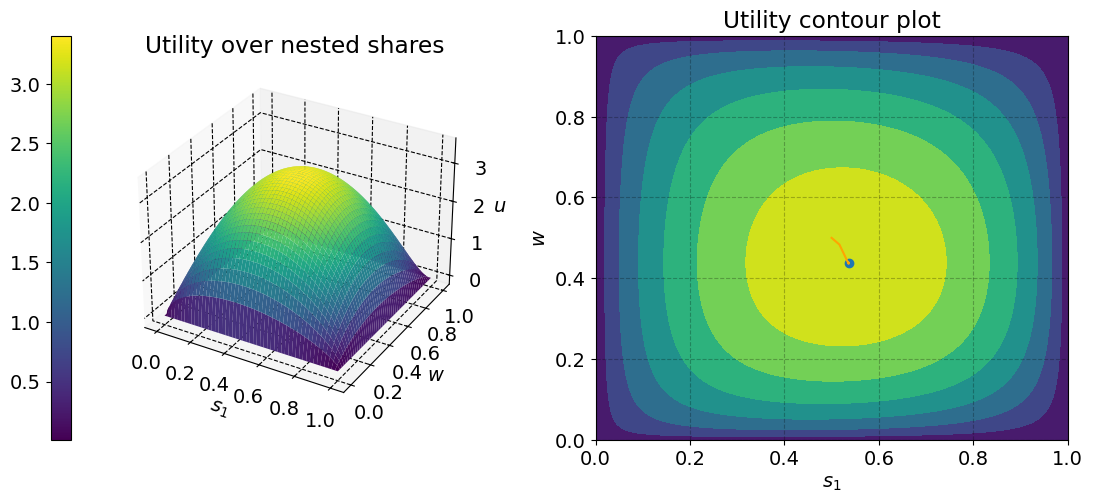

In [19]:
opt_grid = model.solve_grid(N=200)
opt_lbfgsb = model.solve()

fig = model.plot_grid(opt_grid)
ax = fig.axes[2]
ax.plot(opt_lbfgsb.path[:,0],opt_lbfgsb.path[:,1], color="orange")

In [20]:
opt_lbfgsb.path

array([[0.5       , 0.5       ],
       [0.51661738, 0.48338262],
       [0.5360763 , 0.43575106],
       [0.53560667, 0.43965199],
       [0.53562338, 0.43947903]])

In [21]:
solution_complements.res.x

array([0.53562338, 0.43947903])

In [ ]:
path_com = solution_complements.path
xy_values_comp = solution_complements.res.x

distance_comp = np.linalg.norm(path_com - xy_values_comp, axis=1)
log_dis_comp = np.log(distance_comp[:-1]) #dropped the final zero-distance point to avoid log(0)

/var/folders/9f/_qwhm7hj7nx54tbqjl50k1900000gn/T/ipykernel_18206/1606275580.py:5: RuntimeWarning: divide by zero encountered in log
  np.log(distance_comp)


array([-2.65602428, -3.03987393, -5.58456487, -8.65778049,        -inf])

In [ ]:
log_dis_comp = np.log(distance_comp)

/var/folders/9f/_qwhm7hj7nx54tbqjl50k1900000gn/T/ipykernel_18206/1698964917.py:1: RuntimeWarning: divide by zero encountered in log
  log_dis_comp = np.log(distance_comp)


In [24]:
# Checking that the log calculation is correct
np.log(np.sqrt((0.5-0.53562338)**2 + (0.5-0.43947903)**2))

np.float64(-2.6560243037722415)

(-0.15000000000000002, 3.15)

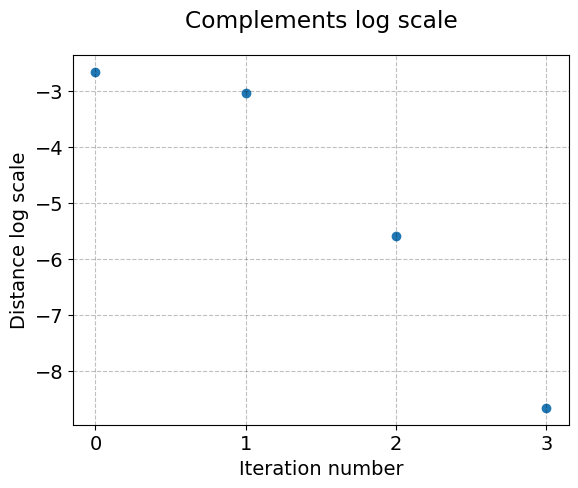

In [25]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.grid(True, ls="--")
ax.scatter(range(len(log_dis_comp)),log_dis_comp)

ax.set_title('Complements log scale',pad=20)
ax.set_xlabel('Iteration number')
ax.set_ylabel('Distance log scale')

ax.set_xticks(range(4))
ax.set_xlim()

##### Bus and trains subtitutes

s1=0.5377
s2=0.3206
s3=0.1417
w=0.6935
u=3.4851


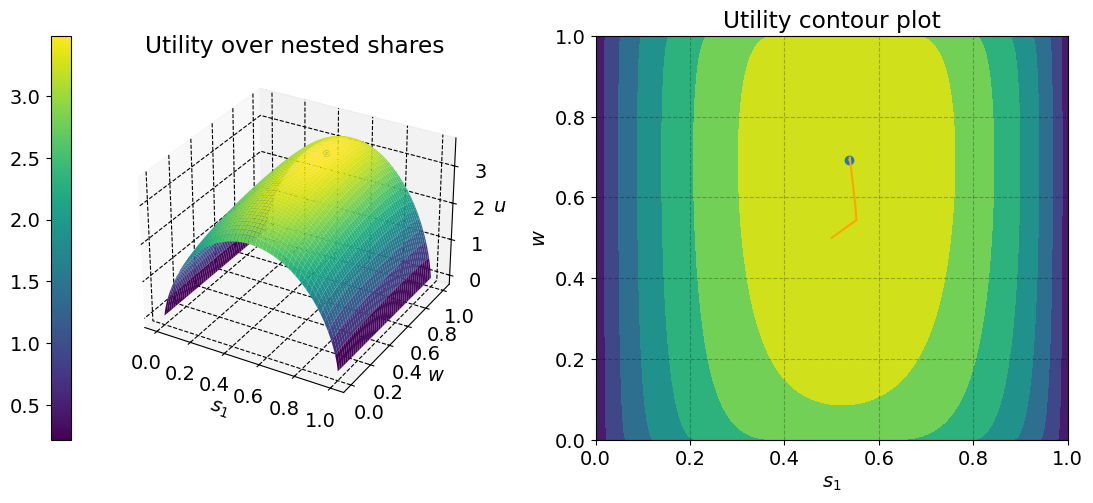

In [26]:
consumer_substitutes = ConsumerClass(par={"sigma_B":3.0})

opt_grid = consumer_substitutes.solve_grid(N=200)
opt_lbfgsb_sub = consumer_substitutes.solve()

fig = consumer_substitutes.plot_grid(opt_grid)
ax = fig.axes[2]
ax.plot(opt_lbfgsb_sub.path[:,0],opt_lbfgsb_sub.path[:,1], color="orange")

In [27]:
opt_lbfgsb_sub.path

array([[0.5       , 0.5       ],
       [0.55264991, 0.54406178],
       [0.55047615, 0.57788281],
       [0.53867585, 0.69929484],
       [0.5381552 , 0.69156192],
       [0.53822567, 0.69230085],
       [0.53822534, 0.69230777]])

In [28]:
path_sub = solution_substitutes.path
xy_values_sub= solution_substitutes.res.x

distance_sub = np.linalg.norm(path_sub - xy_values_sub, axis=1)
np.log(distance_sub)

/var/folders/9f/_qwhm7hj7nx54tbqjl50k1900000gn/T/ipykernel_18206/3906373334.py:5: RuntimeWarning: divide by zero encountered in log
  np.log(distance_sub)


array([ -1.62928341,  -1.90417079,  -2.16213728,  -4.96161912,
        -7.19659223, -11.88039798,         -inf])

In [29]:
log_dis_sub = np.log(distance_sub)

/var/folders/9f/_qwhm7hj7nx54tbqjl50k1900000gn/T/ipykernel_18206/1163028884.py:1: RuntimeWarning: divide by zero encountered in log
  log_dis_sub = np.log(distance_sub)


In [30]:
# Checking that the log calculation is correct
np.log(np.sqrt((0.5-0.53822534)**2 + (0.5-0.69230777)**2))

np.float64(-1.6292834090265513)

(-0.25, 5.25)

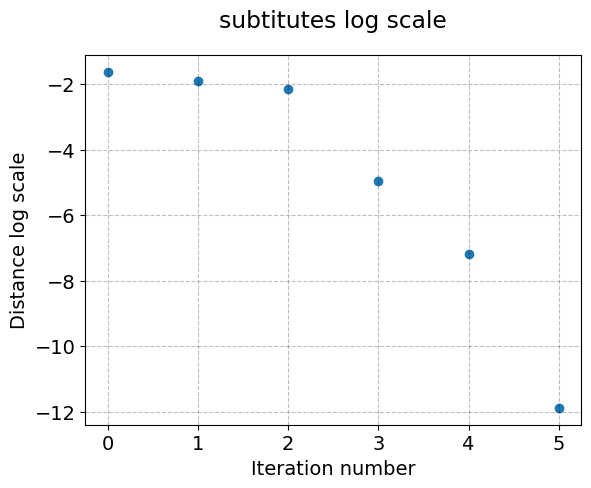

In [31]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.grid(True, ls="--")
ax.scatter(range(len(log_dis_sub)),log_dis_sub)

ax.set_title('subtitutes log scale',pad=20)
ax.set_xlabel('Iteration number')
ax.set_ylabel('Distance log scale')

ax.set_xticks(range(6))
ax.set_xlim()

#### Where does the method make fast progress, and where is it slow

The process is fast when the starting point is close to the optimal point. The closer the starting point the fewer iterations does the method neds. The further away the starting point is from the optimal point, the more iterations it needs and thelonger the methods takes

### 2.2.3 Solving with different starting points

##### Bus and train complements

In [32]:
from Our_Consumer import ConsumerClass

s_point_center = model.solve(s0=np.array([0.5,0.5]))
print(f"u: {-s_point_center.res.fun}, iterations: {s_point_center.res.nit}")

u: 3.401679875985606, iterations: 4


In [33]:
s_point_00 = model.solve(s0=np.array([0,0]))
print(f"u: {-s_point_00.res.fun}, iterations: {s_point_00.res.nit}")

u: 3.401679875987522, iterations: 7


In [34]:
s_point_01 = model.solve(s0=np.array([0,1]))
print(f"u: {-s_point_01.res.fun}, iterations: {s_point_01.res.nit}")

u: 3.401679875988759, iterations: 9


In [35]:
s_point_10 =model.solve(s0=(1,0))
print(f"u: {-s_point_10.res.fun}, iterations: {s_point_10.res.nit}")

u: 6.177356919346663e-11, iterations: 1


In [36]:
s_point_11 =model.solve(s0=(1,1))
print(f"u: {-s_point_11.res.fun}, iterations: {s_point_11.res.nit}")

u: 6.17735691935048e-11, iterations: 1


In [37]:
s_point_random =model.solve(s0=np.array([0.3,0.7]))
print(f"u: {-s_point_random.res.fun}, iterations: {s_point_random.res.nit}")

u: 3.4016798759887488, iterations: 6


##### Bus and trains subtitutes

In [38]:
s1_point_center =consumer_substitutes.solve(s0=np.array([0.5,0.5]))
print(f"u: {-s1_point_center.res.fun}, iterations: {s1_point_center.res.nit}")

u: 3.485104590431205, iterations: 6


In [39]:
s1_point_00 =model_subtitutes.solve(s0=np.array([0,0]))
print(f"u: {-s1_point_00.res.fun}, iterations: {s1_point_00.res.nit}")

u: 3.485104590420858, iterations: 18


In [40]:
s1_point_01 =model_subtitutes.solve(s0=np.array([0,1]))
print(f"u: {-s1_point_01.res.fun}, iterations: {s1_point_01.res.nit}")

u: 3.4851045904312117, iterations: 17


In [41]:
s1_point_10 =model_subtitutes.solve(s0=np.array([1,0]))
print(f"u: {-s1_point_10.res.fun}, iterations: {s1_point_10.res.nit}")

u: 3.4851045904312117, iterations: 18


In [42]:
s1_point_11 =model_subtitutes.solve(s0=np.array([1,1]))
print(f"u: {-s1_point_11.res.fun}, iterations: {s1_point_11.res.nit}")

u: 3.485104590431182, iterations: 16


In [43]:
s1_point_random =model_subtitutes.solve(s0=np.array([0.3,0.7]))
print(f"u: {-s1_point_random.res.fun}, iterations: {s1_point_random.res.nit}")

u: 3.4851045904309936, iterations: 7


#### Results and number of iterations

When bus and trains tickets are complements the L-BFGS-B method doesn´t reach the same u-value regardless of the starting point. At the two corners (1,0) and (1,1) it returns a really small value of u = 6.18e-11. This happens because s2 and s3 are zero when s1=1, which makes it report success = True even though only one iteration has occurd.

When bus and train tickets are substitutes the L-BFGS-B method reaches the same u-value regardless of the starting point. The choice of starting point only affects the number of iterations needed to reach the optimum point.

### 2.2.4 Varying the settings

In [44]:
# Getting the names of the variables

model.solve(s0=np.array([0.5,0.5]), options={'ftol':1e-1})

namespace(s1=np.float64(0.5166173782962519),
          w=np.float64(0.4833826217037481),
          s2=np.float64(0.23365875896518887),
          s3=np.float64(0.24972386273855926),
          u=np.float64(3.383679588967678),
          path=array([[0.5       , 0.5       ],
                      [0.51661738, 0.48338262]]),
          res=  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
                success: True
                 status: 0
                    fun: -3.383679588967678
                      x: [ 5.166e-01  4.834e-01]
                    nit: 1
                    jac: [-3.137e-01  6.724e-01]
                   nfev: 9
                   njev: 3
               hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>)

#### Bus and train complements

In [45]:
for ftol in [10**-4,10**-8,10**-12,10**-16]:
    report = model.solve(s0=np.array([0.5,0.5]), options={'ftol':ftol})
    print(ftol, report.res.x, -report.res.fun, report.res.nfev)

0.0001 [0.53560667 0.43965199] 3.4016796321211804 15
1e-08 [0.53562338 0.43947903] 3.401679875985606 18
1e-12 [0.53562338 0.43947903] 3.401679875985606 18
1e-16 [0.53562338 0.43947903] 3.401679875985606 18


In [46]:
import pandas as pd


table = []
for ftol in [10**-4,10**-8,10**-12,10**-16]:
    report = model.solve(s0=np.array([0.5,0.5]), options={'ftol':ftol})
    table.append({
        "ftol" : ftol,
        "s1" : report.res.x[0], 
        "w" : report.res.x[1],
        "u" : -report.res.fun,
        "iterations" : report.res.nfev, 
    })

ftol_compl = pd.DataFrame(table)
ftol_compl.style.format({
"ftol": "{:.1e}",
"s1": "{:.4f}",
"w": "{:.4f}",
"u": "{:.8f}",
})

,ftol,s1,w,u,iterations
0,1.0e-04,0.5356,0.4397,3.40167963,15
1,1.0e-08,0.5356,0.4395,3.40167988,18
2,1.0e-12,0.5356,0.4395,3.40167988,18
3,1.0e-16,0.5356,0.4395,3.40167988,18


In [47]:
for gtol in [10**-2,10**-5,10**-8,10**-12]:
    report = model.solve(s0=np.array([0.5,0.5]), options={'gtol':gtol})
    print(gtol, report.res.x, -report.res.fun, report.res.nfev)

0.01 [0.53560667 0.43965199] 3.4016796321211804 15
1e-05 [0.53562338 0.43947903] 3.401679875985606 18
1e-08 [0.53562357 0.43947843] 3.401679875988761 21
1e-12 [0.53562357 0.43947843] 3.401679875988761 21


In [48]:
table = []
for gtol in [10**-2,10**-5,10**-8,10**-12]:
    report = model.solve(s0=np.array([0.5,0.5]), options={'gtol':gtol})
    table.append({
        "gtol" : gtol,
        "s1" : report.res.x[0],
        "w" : report.res.x[1],
        "u" : -report.res.fun,
        "iterations" : report.res.nfev
    })

gtol_compl = pd.DataFrame(table)
gtol_compl.style.format({
"gtol": "{:.1e}",
"s1": "{:.4f}",
"w": "{:.4f}",
"u": "{:.8f}",
})


,gtol,s1,w,u,iterations
0,1.0e-02,0.5356,0.4397,3.40167963,15
1,1.0e-05,0.5356,0.4395,3.40167988,18
2,1.0e-08,0.5356,0.4395,3.40167988,21
3,1.0e-12,0.5356,0.4395,3.40167988,21


#### Bus and trains subtitutes

In [49]:
model.par.sigma_B = 3.0

table = []
for ftol in [10**-4,10**-8,10**-12,10**-16]:
    report = model.solve(s0=np.array([0.5,0.5]), options={'ftol':ftol})
    table.append({
        "ftol" : ftol,
        "s1" : report.res.x[0],
        "w" : report.res.x[1],
        "u" : -report.res.fun,
        "iterations" : report.res.nfev
    })

ftol_sub = pd.DataFrame(table)
ftol_sub.style.format({
"ftol": "{:.1e}",
"s1": "{:.4f}",
"w": "{:.4f}",
"u": "{:.8f}",
})

,ftol,s1,w,u,iterations
0,1.0e-04,0.5382,0.6916,3.48510385,21
1,1.0e-08,0.5382,0.6923,3.48510459,27
2,1.0e-12,0.5382,0.6923,3.48510459,27
3,1.0e-16,0.5382,0.6923,3.48510459,27


In [ ]:
model.par.sigma_B = 3.0

table = []
for gtol in [10**-2,10**-5,10**-8,10**-12]:
    report = model.solve(s0=np.array([0.5,0.5]), options={'gtol':gtol})
    table.append({
        "gtol" : gtol,
        "s1" : report.res.x[0],
        "w" : report.res.x[1],
        "u" : -report.res.fun,
        "iterations" : report.res.nfev
    })

gtol_sub = pd.DataFrame(table) #bug fixed: overrwriting the previous gtol_compl variable with the new gtol_sub variable
gtol_sub.style.format({ #same as above
"gtol": "{:.1e}",
"s1": "{:.4f}",
"w": "{:.4f}",
"u": "{:.8f}",
})

,gtol,s1,w,u,iterations
0,1.0e-02,0.5382,0.6916,3.48510385,21
1,1.0e-05,0.5382,0.6923,3.48510459,27
2,1.0e-08,0.5382,0.6923,3.48510459,27
3,1.0e-12,0.5382,0.6923,3.48510459,27


### 2.2.5 What settings would we use

We would use the settings ftol=10**-4 and gtol=10**-5, because theese gives the highest values of u while limitting the number of iritations needed.
A tigher tolerance isn´t alway a better choice, beacause at some point it no longer improves u, but inly increases the number of iritations needed. This is also the case in 2.2.4, where u at some point stays the same, but the number og iritations increase as the valuse of ftol and gtol gets tightened further.

## 4 Lump-sum taxes and product taxes

### 4.2

#### Calibration: Complements

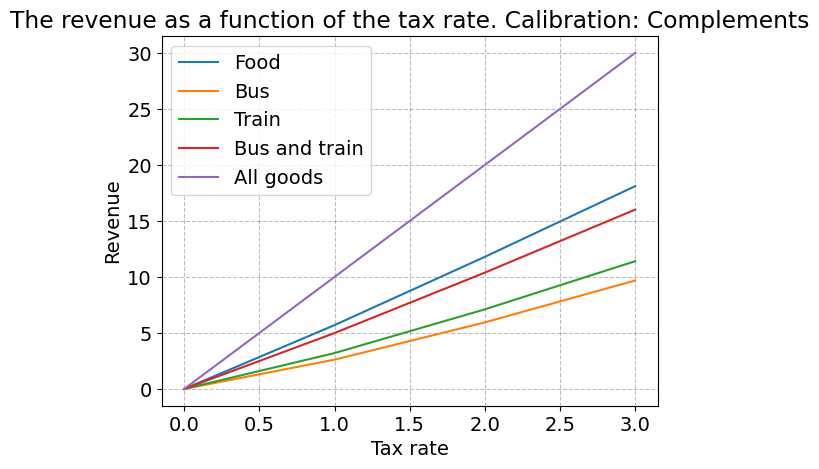

In [51]:
from Government import GovernmentClass

#Only food
food_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = gov.revenue_and_utility(tau,(1,))
    food_tax.append(x[0])

#only bus
bus_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = gov.revenue_and_utility(tau,(2,))
    bus_tax.append(x[0])

#Only train
train_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = gov.revenue_and_utility(tau,(3,))
    train_tax.append(x[0])

#Bus and train tax
bus_and_train_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = gov.revenue_and_utility(tau,(2,3))
    bus_and_train_tax.append(x[0])

#Tax on all goods
all_goods_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = gov.revenue_and_utility(tau,(1,2,3))
    all_goods_tax.append(x[0])

taxes = [0,1,2,3]

plt.plot(taxes, food_tax, label="Food")
plt.plot(taxes, bus_tax, label="Bus")
plt.plot(taxes, train_tax, label="Train")
plt.plot(taxes, bus_and_train_tax, label="Bus and train")
plt.plot(taxes, all_goods_tax, label="All goods")

plt.xlabel("Tax rate")
plt.ylabel("Revenue")
plt.title("The revenue as a function of the tax rate. Calibration: Complements")

plt.legend(loc="upper left")  # Box
plt.grid(True)
plt.show()

#### Calibration: Substitutes

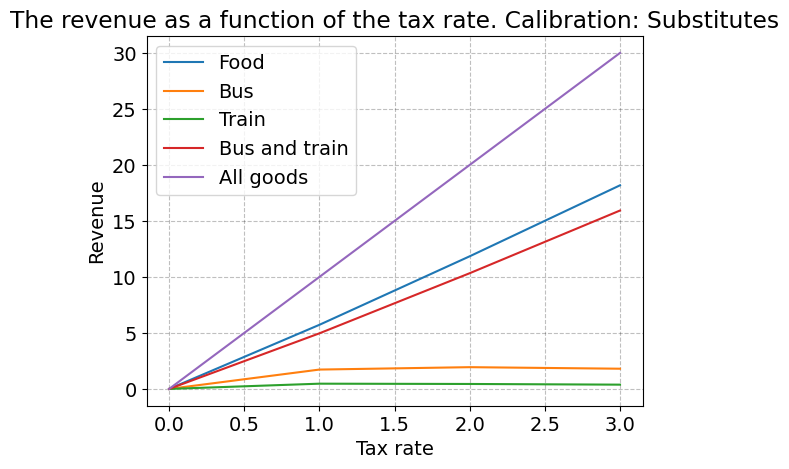

In [52]:
from Government import GovernmentClass

#Changing sigma_B so train and bus are substitutes
model_subtitutes = GovernmentClass(par={"sigma_B":3.0})

#Only food
food_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = model_subtitutes.revenue_and_utility(tau,(1,))
    food_tax.append(x[0])

#only bus
bus_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = model_subtitutes.revenue_and_utility(tau,(2,))
    bus_tax.append(x[0])

#Only train
train_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = model_subtitutes.revenue_and_utility(tau,(3,))
    train_tax.append(x[0])

#Bus and train tax
bus_and_train_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = model_subtitutes.revenue_and_utility(tau,(2,3))
    bus_and_train_tax.append(x[0])

#Tax on all goods
all_goods_tax = []
for tau in range(4):   
    gov = GovernmentClass()
    x = model_subtitutes.revenue_and_utility(tau,(1,2,3))
    all_goods_tax.append(x[0])

taxes = [0,1,2,3]

plt.plot(taxes, food_tax, label="Food")
plt.plot(taxes, bus_tax, label="Bus")
plt.plot(taxes, train_tax, label="Train")
plt.plot(taxes, bus_and_train_tax, label="Bus and train")
plt.plot(taxes, all_goods_tax, label="All goods")

plt.xlabel("Tax rate")
plt.ylabel("Revenue")
plt.title("The revenue as a function of the tax rate. Calibration: Substitutes")

plt.legend(loc="upper left")  # Box
plt.grid(True)
plt.show()


### 4.3

Which of the curves have a top and which just keep rising?

The curves which represent tax on the bus and tax on the train have a top in the case where bus and train are substitutes. The other curves are rising in the case with bus and train as substitutes. In the case where bus and train are complements all curves continues rising.

In [53]:
# The revenue-maximizing rate and the largest possible revenue where there is a top.
gor = GovernmentClass(par={"sigma_B":3.0})

#train_max = optimize.minimize(gor.revenue_and_utility(tau,(3,)), 0,method='L-BFGS-B', bounds=(0,3))

train_max = optimize.minimize_scalar(lambda tau: -gor.revenue_and_utility(tau, (3,))[0], bounds=(0, 3), method="bounded")

tau_optimal = train_max.x
max_revenue = -train_max.fun

print("Optimal tau:", tau_optimal)
print("Max revenue:", max_revenue)

print(train_max)

Optimal tau: 1.2126392444610659
Max revenue: 0.47308815344444427
 message: Solution found.
 success: True
  status: 0
     fun: -0.47308815344444427
       x: 1.2126392444610659
     nit: 19
    nfev: 19


As seen in the calculations above, the optimal tax on the train tickets is 1.212 which gives a revenue of 0.473

### 4.4

#### Calibration: Complements

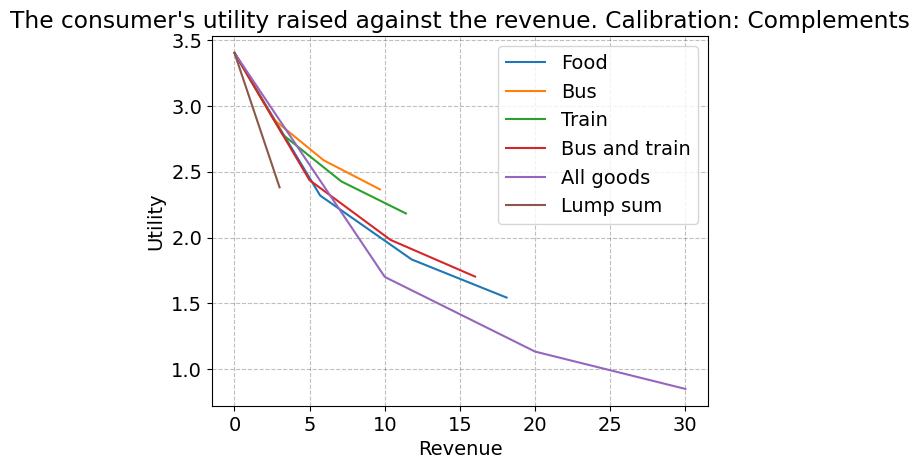

In [54]:
from Government import GovernmentClass

#Only food
food_rev = []
food_util = []
for tau in range(4):   
    gov = GovernmentClass()
    R,u = gov.revenue_and_utility(tau,(1,))
    food_rev.append(R)
    food_util.append(u)

#only bus
bus_rev = []
bus_util = []
for tau in range(4):   
    gov = GovernmentClass()
    R, u = gov.revenue_and_utility(tau,(2,))
    bus_rev.append(R)
    bus_util.append(u)

#Only train
train_rev = []
train_util = []
for tau in range(4):   
    gov = GovernmentClass()
    R, u = gov.revenue_and_utility(tau,(3,))
    train_rev.append(R)
    train_util.append(u)

#Bus and train tax
bus_and_train_rev = []
bus_and_train_util = []
for tau in range(4):   
    gov = GovernmentClass()
    R, u = gov.revenue_and_utility(tau,(2,3))
    bus_and_train_rev.append(R)
    bus_and_train_util.append(u)

#Tax on all goods
all_goods_rev = []
all_goods_util = []
for tau in range(4):   
    gov = GovernmentClass()
    R, u = gov.revenue_and_utility(tau,(1,2,3))
    all_goods_rev.append(R)
    all_goods_util.append(u)

#Lump sump
lump_sum_rev = []
lump_sum_util = []
for T in range(4):
    gov = GovernmentClass()
    R, u = gov.revenue_and_utility_lump_sum(T)
    lump_sum_rev.append(R)
    lump_sum_util.append(u)

#Plotting the graph
plt.plot(food_rev, food_util, label="Food")
plt.plot(bus_rev, bus_util, label="Bus")
plt.plot(train_rev, train_util, label="Train")
plt.plot(bus_and_train_rev, bus_and_train_util, label="Bus and train")
plt.plot(all_goods_rev, all_goods_util, label="All goods")
plt.plot(lump_sum_rev, lump_sum_util, label="Lump sum")

plt.xlabel("Revenue")
plt.ylabel("Utility")
plt.title("The consumer's utility raised against the revenue. Calibration: Complements")

plt.legend(loc="upper right")  # Box
plt.grid(True)
plt.show()

#### Calibration: Substitutes

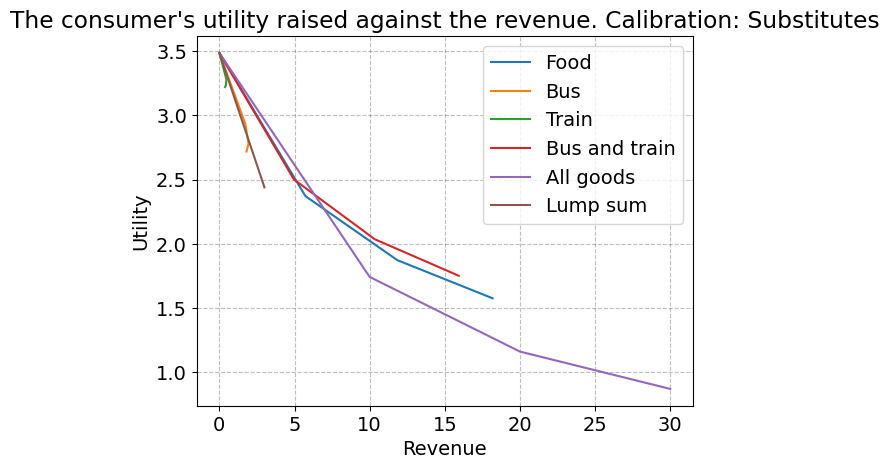

In [55]:
from Government import GovernmentClass

#Only food
food_rev = []
food_util = []
for tau in range(4):   
    gov = GovernmentClass(par={"sigma_B":3.0})
    R,u = gov.revenue_and_utility(tau,(1,))
    food_rev.append(R)
    food_util.append(u)

#only bus
bus_rev = []
bus_util = []
for tau in range(4):   
    gov = GovernmentClass(par={"sigma_B":3.0})
    R, u = gov.revenue_and_utility(tau,(2,))
    bus_rev.append(R)
    bus_util.append(u)

#Only train
train_rev = []
train_util = []
for tau in range(4):   
    gov = GovernmentClass(par={"sigma_B":3.0})
    R, u = gov.revenue_and_utility(tau,(3,))
    train_rev.append(R)
    train_util.append(u)

#Bus and train tax
bus_and_train_rev = []
bus_and_train_util = []
for tau in range(4):   
    gov = GovernmentClass(par={"sigma_B":3.0})
    R, u = gov.revenue_and_utility(tau,(2,3))
    bus_and_train_rev.append(R)
    bus_and_train_util.append(u)

#Tax on all goods
all_goods_rev = []
all_goods_util = []
for tau in range(4):   
    gov = GovernmentClass(par={"sigma_B":3.0})
    R, u = gov.revenue_and_utility(tau,(1,2,3))
    all_goods_rev.append(R)
    all_goods_util.append(u)

#Lump sump
lump_sum_rev = []
lump_sum_util = []
for T in range(4):
    gov = GovernmentClass(par={"sigma_B":3.0})
    R, u = gov.revenue_and_utility_lump_sum(T)
    lump_sum_rev.append(R)
    lump_sum_util.append(u)

#Plotting the graph
plt.plot(food_rev, food_util, label="Food")
plt.plot(bus_rev, bus_util, label="Bus")
plt.plot(train_rev, train_util, label="Train")
plt.plot(bus_and_train_rev, bus_and_train_util, label="Bus and train")
plt.plot(all_goods_rev, all_goods_util, label="All goods")
plt.plot(lump_sum_rev, lump_sum_util, label="Lump sum")

plt.xlabel("Revenue")
plt.ylabel("Utility")
plt.title("The consumer's utility raised against the revenue. Calibration: Substitutes")

plt.legend(loc="upper right")  # Box
plt.grid(True)
plt.show()

Which instrument is the cheapest way to raise a given revenue, and does the ranking depend on the calibration?
When bus and train are substitutes the cheapest solution is to set the product tax on bus and train together. This curve, which is colored red in this case, are the one lying most in the upper right corner which means that for a given revenue, the utility is higher.
When bus and train are complements it is cheapest to put the the product tax on bus tickets.
For both cases the lump sum tax is a expensive way to tax the consumer. A reason for this might be that the consumer cannot change their liability.

### 4.5

#### Calibration: Complements

In [ ]:
from Government import GovernmentClass
import pandas as pd

gov = GovernmentClass()

R_target = 0.02

#Food
tau_food = gov.find_tax_rate(
    R_target,
    goods=(1,),
    bracket=(1e-10, 1.0)
)

R_food, u_food = gov.revenue_and_utility(tau_food, goods=(1,))

print(f"tau_food = {tau_food:.6f}")
print(f"Revenue_food = {R_food:.6f}")
print(f"Utility_food = {u_food:.6f}")

#Bus
tau_bus = gov.find_tax_rate(
    R_target,
    goods=(2,),
    bracket=(1e-10, 1.0)
)

R_bus, u_bus = gov.revenue_and_utility(tau_bus, goods=(2,))

print(f"tau_bus = {tau_bus:.6f}")
print(f"Revenue_bus = {R_bus:.6f}")
print(f"Utility_bus = {u_bus:.6f}")

#Train
tau_train = gov.find_tax_rate(
    R_target,
    goods=(3,),
    bracket=(1e-10, 1.0)
)

R_train, u_train = gov.revenue_and_utility(tau_train, goods=(3,)) #fixed to good 3 for train

print(f"tau_train = {tau_train:.6f}")
print(f"Revenue_train = {R_train:.6f}")
print(f"Utility_train = {u_train:.6f}")

#Bus and train
tau_bus_and_train = gov.find_tax_rate(
    R_target,
    goods=(2,3),
    bracket=(1e-10, 1.0)
)

R_bus_and_train, u_bus_and_train = gov.revenue_and_utility(tau_bus_and_train, goods=(2,3))

print(f"tau_bus_and_train = {tau_bus_and_train:.6f}")
print(f"Revenue_bus_and_train = {R_bus_and_train:.6f}")
print(f"Utility_bus_and_train = {u_bus_and_train:.6f}")

#All goods
tau_all_goods = gov.find_tax_rate(
    R_target,
    goods=(1,2,3),
    bracket=(1e-10, 1.0)
)

R_all_goods, u_all_goods = gov.revenue_and_utility(tau_all_goods, goods=(1,2,3))

print(f"tau_all_goods = {tau_all_goods:.6f}")
print(f"Revenue_all_goods = {R_all_goods:.6f}")
print(f"Utility_all_goods = {u_all_goods:.6f}")

import pandas as pd

data = {
    "Tax": [
        "Food",
        "Bus",
        "Train",
        "Bus and Train",
        "All goods"
    ],
    "Tax rate": [
        tau_food,
        tau_bus,
        tau_train,
        tau_bus_and_train,
        tau_all_goods
    ],
    "Revenue": [
        R_food,
        R_bus,
        R_train,
        R_bus_and_train,
        R_all_goods
    ],
    "Utility": [
        u_food,
        u_bus,
        u_train,
        u_bus_and_train,
        u_all_goods
    ]
}

df = pd.DataFrame(data)

df

tau_food = 0.003733
Revenue_food = 0.020000
Utility_food = 3.394897
tau_bus = 0.009763
Revenue_bus = 0.020000
Utility_bus = 3.394929
tau_train = 0.007665
Revenue_train = 0.015688
Utility_train = 3.396376
tau_bus_and_train = 0.004305
Revenue_bus_and_train = 0.020000
Utility_bus_and_train = 3.394899
tau_all_goods = 0.002000
Revenue_all_goods = 0.020000
Utility_all_goods = 3.394890


,Tax,Tax rate,Revenue,Utility
0,Food,0.003733,0.020000,3.394897
1,Bus,0.009763,0.020000,3.394929
2,Train,0.007665,0.015688,3.396376
3,Bus and Train,0.004305,0.020000,3.394899
4,All goods,0.002000,0.020000,3.394890


#### Calibration: Substitutes

In [ ]:
from Government import GovernmentClass

gov = GovernmentClass(par={"sigma_B":3.0})

R_target = 0.02

#Food
tau_food = gov.find_tax_rate(
    R_target,
    goods=(1,),
    bracket=(1e-10, 1.0)
)

R_food, u_food = gov.revenue_and_utility(tau_food, goods=(1,))

print(f"tau_food = {tau_food:.6f}")
print(f"Revenue_food = {R_food:.6f}")
print(f"Utility_food = {u_food:.6f}")

#Bus
tau_bus = gov.find_tax_rate(
    R_target,
    goods=(2,),
    bracket=(1e-10, 1.0)
)

R_bus, u_bus = gov.revenue_and_utility(tau_bus, goods=(2,))

print(f"tau_bus = {tau_bus:.6f}")
print(f"Revenue_bus = {R_bus:.6f}")
print(f"Utility_bus = {u_bus:.6f}")

#Train
tau_train = gov.find_tax_rate(
    R_target,
    goods=(3,),
    bracket=(1e-10, 1.0)
)

R_train, u_train = gov.revenue_and_utility(tau_train, goods=(3,)) #fixed to good 3 for train

print(f"tau_train = {tau_train:.6f}")
print(f"Revenue_train = {R_train:.6f}")
print(f"Utility_train = {u_train:.6f}")

#Bus and train
tau_bus_and_train = gov.find_tax_rate(
    R_target,
    goods=(2,3),
    bracket=(1e-10, 1.0)
)

R_bus_and_train, u_bus_and_train = gov.revenue_and_utility(tau_bus_and_train, goods=(2,3))

print(f"tau_bus_and_train = {tau_bus_and_train:.6f}")
print(f"Revenue_bus_and_train = {R_bus_and_train:.6f}")
print(f"Utility_bus_and_train = {u_bus_and_train:.6f}")

#All goods
tau_all_goods = gov.find_tax_rate(
    R_target,
    goods=(1,2,3),
    bracket=(1e-10, 1.0)
)

R_all_goods, u_all_goods = gov.revenue_and_utility(tau_all_goods, goods=(1,2,3))

print(f"tau_all_goods = {tau_all_goods:.6f}")
print(f"Revenue_all_goods = {R_all_goods:.6f}")
print(f"Utility_all_goods = {u_all_goods:.6f}")

import pandas as pd

data = {
    "Tax": [
        "Food",
        "Bus",
        "Train",
        "Bus and Train",
        "All goods"
    ],
    "Tax rate": [
        tau_food,
        tau_bus,
        tau_train,
        tau_bus_and_train,
        tau_all_goods
    ],
    "Revenue": [
        R_food,
        R_bus,
        R_train,
        R_bus_and_train,
        R_all_goods
    ],
    "Utility": [
        u_food,
        u_bus,
        u_train,
        u_bus_and_train,
        u_all_goods
    ]
}

df = pd.DataFrame(data)

df

tau_food = 0.003715
Revenue_food = 0.020000
Utility_food = 3.478155
tau_bus = 0.006277
Revenue_bus = 0.020000
Utility_bus = 3.478151
tau_train = 0.014351
Revenue_train = 0.045523
Utility_train = 3.469326
tau_bus_and_train = 0.004329
Revenue_bus_and_train = 0.020000
Utility_bus_and_train = 3.478158
tau_all_goods = 0.002000
Revenue_all_goods = 0.020000
Utility_all_goods = 3.478148


,Tax,Tax rate,Revenue,Utility
0,Food,0.003715,0.020000,3.478155
1,Bus,0.006277,0.020000,3.478151
2,Train,0.014351,0.045523,3.469326
3,Bus and Train,0.004329,0.020000,3.478158
4,All goods,0.002000,0.020000,3.478148


The revenue on the train ticket differs from 0.02 in both cases. When bus and train are complements, the revenue on the train is less than 0.02. In the other case where bus and train are substitutes, the revenue on the train tickets are larger.
To rank the instruments, the instrument with the highest utility wins. In the case with bus and train as complements, the train tickets gives highest utility. After the train it is the bus tickets.
In the case where bus and train are substitutes, bus and train together gives the highest utility.